# Validation — Spectrum comparison: 3062330 vs 657632

**Goal**: Test 1 from the 12CO/13CO disagreement analysis.  
Visually compare the best-fit model spectra of the two retrievals against the same two-night flux-calibrated data to understand why the absolute-flux retrieval (3062330) finds 12CO/13CO ≈ 25 while the Ruffio retrieval (657632) finds ≈ 51.

| Retrieval | Likelihood | 12CO/13CO | T_anchor | [C/H] |
|-----------|-----------|-----------|----------|-------|
| 3062330 (007PM-EQ-GP) | Gaussian, absolute flux | 24.7 | 2163 K | −0.475 |
| 657632 (008PM-EQ-RUFFIO) | Ruffio φ-per-chip | 50.9 | 1955 K | −0.249 |

**Sections**:
1. Full K-band spectrum data vs model (absolute flux for 3062330; per-chip normalised for 657632)
2. Per-chip φ analysis — quantify inter-chip flux calibration slope in 3062330
3. 13CO bandhead zoom (2338–2370 nm) — direct comparison of 13CO feature depths

## §0  Configuration

In [1]:
from pathlib import Path

WORKPATH     = Path('/data2/peng')
COMBINED_DIR = WORKPATH / 'combined_two_nights'
RETR_BASE    = WORKPATH / 'retrievals'

RID_C  = '2195179_N600_ev0.5_NormNone_PerChipScaleFalse'
RID_D  = '2777844_N600_ev0.5_NormNone_PerChipScaleTrue'
DIR_C  = RETR_BASE / RID_C
DIR_D  = RETR_BASE / RID_D
LBL_C  = '2195179 (abs-flux)'
LBL_D  = '2777844 (Ruffio)'
COL_C  = '#d62728'   # red
COL_D  = '#1f77b4'   # blue

# Night-1 barycentric correction (km/s, Earth toward DH Tau)
# Model wavelengths are topocentric; shift to barycentric: λ_bary = λ_topo × (1 + VCORR/c)
VCORR_N1_KMS = -15.37101

print('2195179 dir exists:', DIR_C.exists())
print('2777844 dir exists:', DIR_D.exists())
print('Combined data dir :', COMBINED_DIR.exists())

2195179 dir exists: True
2777844 dir exists: True
Combined data dir : True


## §1  Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy import constants as const

plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})
C_KMS = const.c.to('km/s').value
print('C_KMS =', C_KMS)

C_KMS = 299792.458


## §2  Load data and models

In [3]:
# ── Combined two-night flux-calibrated data (barycentric, W/m²/μm) ──────────
spec3d  = np.load(COMBINED_DIR / 'extracted_spectra_combined_two_nights_flux_cal.npy')    # (3,5,2048)
err3d   = np.load(COMBINED_DIR / 'extracted_spectra_combined_two_nights_flux_cal_err.npy')# (3,5,2048)
wave3d  = np.load(COMBINED_DIR / 'WLEN_combined_two_nights_bary.npy')                     # (3,5,2048) nm bary

nDet, nOrd, nPix = spec3d.shape
print(f'Data: {spec3d.shape}, median = {np.nanmedian(spec3d):.3e} W/m²/μm')

# Flat 1-D arrays (sorted by wavelength) — used for full-spectrum plots
spec_flat = spec3d.ravel().copy()
err_flat  = err3d.ravel().copy()
wave_flat = wave3d.ravel().copy()
spec_flat[spec_flat == 0] = np.nan
err_flat[err_flat   == 0] = np.nan
valid = np.isfinite(spec_flat) & np.isfinite(wave_flat)
idx   = np.argsort(wave_flat[valid])
wave_d = wave_flat[valid][idx]
flux_d = spec_flat[valid][idx]
err_d  = err_flat[valid][idx]
print(f'Valid pixels: {len(wave_d)}, range {wave_d.min():.1f}–{wave_d.max():.1f} nm')

Data: (3, 5, 2048), median = 9.030e-16 W/m²/μm
Valid pixels: 24964, range 2063.8–2470.6 nm


In [4]:
def load_model(retr_dir, vcorr_kms, label):
    """Load model wave+flux from a retrieval directory and shift to barycentric frame."""
    wm_topo = np.load(retr_dir / 'retrieval_model_wave.npy')
    fm      = np.load(retr_dir / 'retrieval_model_flux.npy')
    fms     = np.load(retr_dir / 'retrieval_model_flux_scaled.npy')
    fm      = np.where(np.isinf(fm),  np.nan, fm)
    fms     = np.where(np.isinf(fms), np.nan, fms)
    # Topocentric → barycentric
    wm_bary = wm_topo * (1.0 + vcorr_kms / C_KMS)
    idx     = np.argsort(wm_bary)
    wm      = wm_bary[idx]
    fm      = fm[idx]
    fms     = fms[idx]
    ok      = np.isfinite(fm) & np.isfinite(wm)
    print(f'{label}: {ok.sum()} valid pixels, flux range {np.nanmin(fm):.3e}–{np.nanmax(fm):.3e}')
    return wm, fm, fms, ok

wm_C, fm_C, fms_C, ok_C = load_model(DIR_C, VCORR_N1_KMS, LBL_C)
wm_D, fm_D, fms_D, ok_D = load_model(DIR_D, VCORR_N1_KMS, LBL_D)

2195179 (abs-flux): 24950 valid pixels, flux range 2.893e-16–1.242e-15
2777844 (Ruffio): 24950 valid pixels, flux range 9.764e+04–3.819e+05


## §3  Full K-band spectrum — data vs model

**3062330**: both data and model are in W/m²/μm on an absolute scale. We normalise by their respective global medians only for display (so the y-axis is dimensionless ratio ≈ 1).  
**657632**: `flux_scaled` is the Ruffio per-chip scaled model (already ≈ per-chip normalised). We normalise the data per-chip by chip median to match.

In [5]:
# ── Build per-chip normalised data 1-D array (for 657632 comparison) ──────
spec_norm3d = np.full_like(spec3d, np.nan)
chip_medians = np.full((nDet, nOrd), np.nan)
for d in range(nDet):
    for o in range(nOrd):
        chip = spec3d[d, o]
        valid_chip = np.isfinite(chip) & (chip != 0)
        if valid_chip.sum() > 10:
            med = np.nanmedian(chip[valid_chip])
            chip_medians[d, o] = med
            spec_norm3d[d, o] = chip / med

spec_norm_flat = spec_norm3d.ravel().copy()
valid_n = np.isfinite(spec_norm_flat) & np.isfinite(wave_flat)
idx_n   = np.argsort(wave_flat[valid_n])
wave_dn = wave_flat[valid_n][idx_n]
flux_dn = spec_norm_flat[valid_n][idx_n]
print(f'Per-chip-norm data: {len(wave_dn)} pixels, range {flux_dn[np.isfinite(flux_dn)].min():.3f}–{flux_dn[np.isfinite(flux_dn)].max():.3f}')

Per-chip-norm data: 24964 pixels, range -1.088–2.841


In [6]:
def block_bin(wave, flux, bin_size=10):
    n     = len(wave)
    n_bin = n // bin_size
    wb = np.full(n_bin, np.nan)
    fb = np.full(n_bin, np.nan)
    for i in range(n_bin):
        sl  = slice(i * bin_size, (i + 1) * bin_size)
        f_s = flux[sl]
        ok  = np.isfinite(f_s)
        if ok.sum() == 0:
            continue
        wb[i] = np.mean(wave[sl][ok])
        fb[i] = np.mean(f_s[ok])
    ok = np.isfinite(fb)
    return wb[ok], fb[ok]

print('block_bin defined.')

block_bin defined.


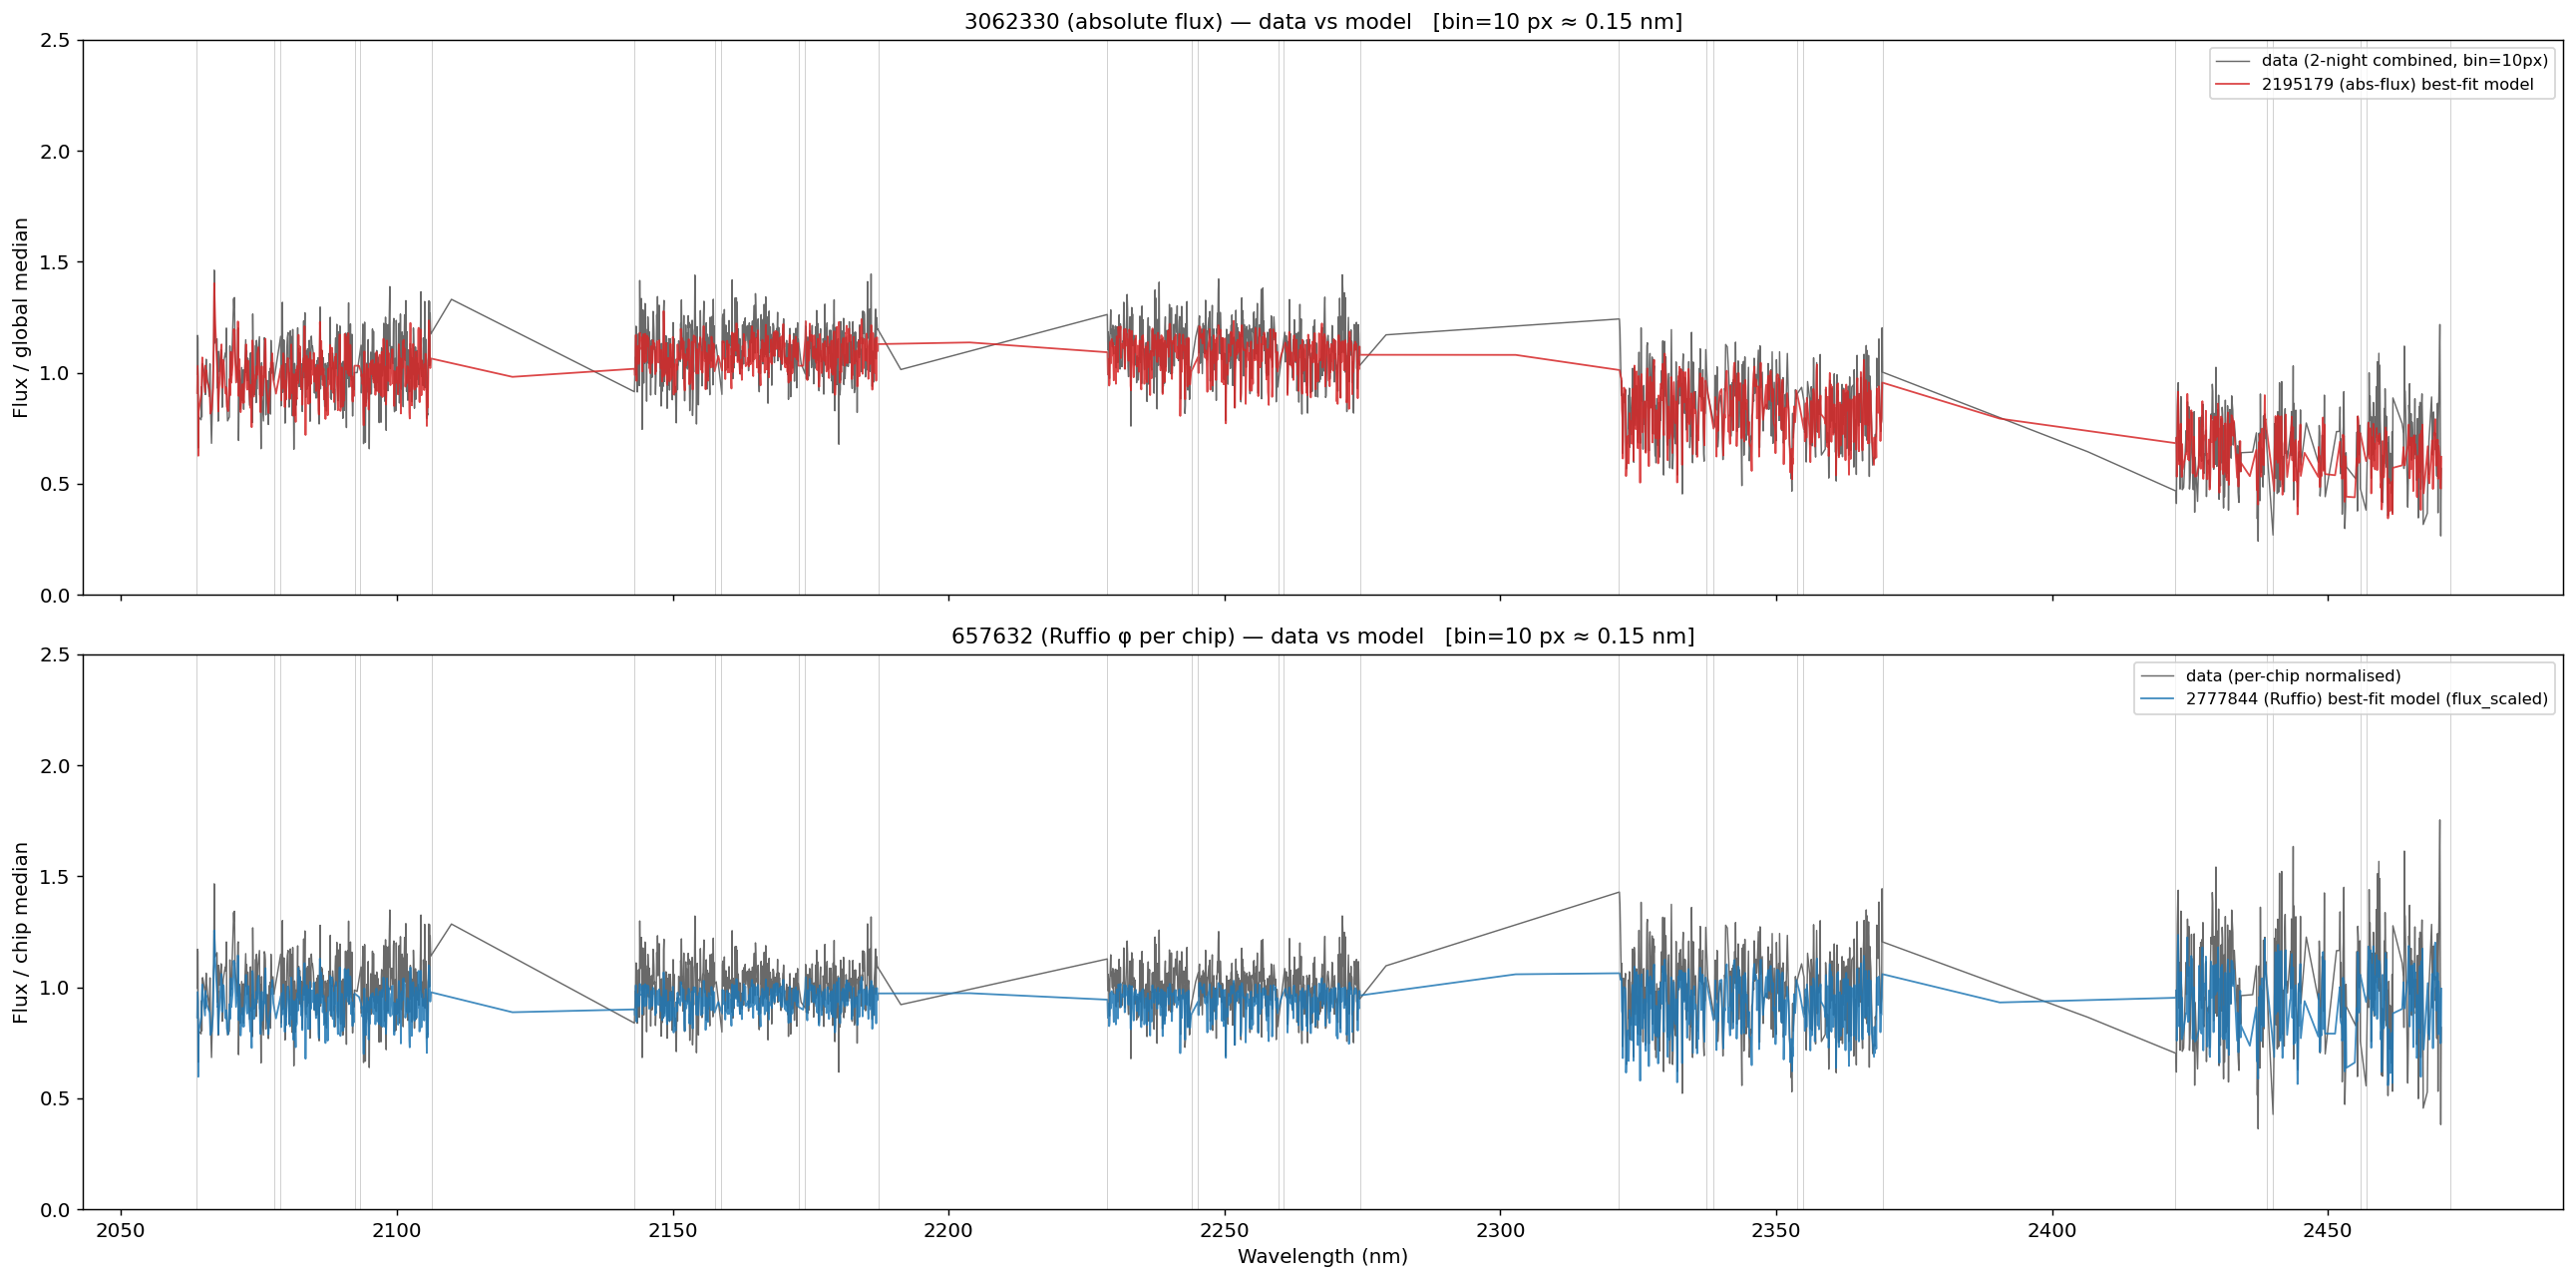

Saved.


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

BIN = 10  # pixels

# ── Panel 1: 3062330 absolute flux (normalised to median=1) ──────────────
ax = axes[0]
med_d = np.nanmedian(flux_d)
med_C = np.nanmedian(fm_C[ok_C])

wb_d, fb_d = block_bin(wave_d, flux_d / med_d, BIN)
wb_C, fb_C = block_bin(wm_C[ok_C], fm_C[ok_C] / med_C, BIN)

ax.plot(wb_d, fb_d, color='#444', lw=0.8, alpha=0.8, label='data (2-night combined, bin=10px)')
ax.plot(wb_C, fb_C, color=COL_C, lw=1.0, alpha=0.85, label=f'{LBL_C} best-fit model')
ax.set_ylabel('Flux / global median')
ax.set_title('3062330 (absolute flux) — data vs model   [bin=10 px ≈ 0.15 nm]', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0.0, 2.5)

# chip boundary lines
for d in range(nDet):
    for o in range(nOrd):
        w_chip = wave3d[d, o]
        ax.axvline(w_chip[w_chip > 0].min(), color='gray', lw=0.4, alpha=0.5)
        ax.axvline(w_chip[w_chip > 0].max(), color='gray', lw=0.4, alpha=0.5)

# ── Panel 2: 657632 per-chip normalised ──────────────────────────────────
ax = axes[1]
wb_dn, fb_dn = block_bin(wave_dn, flux_dn, BIN)
wb_D,  fb_D  = block_bin(wm_D[ok_D], fms_D[ok_D], BIN)

ax.plot(wb_dn, fb_dn, color='#444', lw=0.8, alpha=0.8, label='data (per-chip normalised)')
ax.plot(wb_D,  fb_D,  color=COL_D,  lw=1.0, alpha=0.85, label=f'{LBL_D} best-fit model (flux_scaled)')
ax.set_ylabel('Flux / chip median')
ax.set_xlabel('Wavelength (nm)')
ax.set_title('657632 (Ruffio φ per chip) — data vs model   [bin=10 px ≈ 0.15 nm]', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0.0, 2.5)
for d in range(nDet):
    for o in range(nOrd):
        w_chip = wave3d[d, o]
        ax.axvline(w_chip[w_chip > 0].min(), color='gray', lw=0.4, alpha=0.5)
        ax.axvline(w_chip[w_chip > 0].max(), color='gray', lw=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(DIR_C.parent / 'validation_full_spectrum_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved.')

## §4  Per-chip φ analysis

For each chip k, compute the optimal linear scale factor φ_k that minimises ||d_k − φ_k m_k||²:

$$\phi_k = \frac{\mathbf{d}_k \cdot \mathbf{m}_k}{\mathbf{m}_k \cdot \mathbf{m}_k}$$

For **3062330** (absolute flux): d_k is in W/m²/μm, m_k is the absolute-flux model.  
φ ≈ 1 means the model flux is correctly calibrated.  A slope in φ vs wavelength reveals a systematic inter-chip flux calibration offset in the data or the model continuum.

For **657632** (Ruffio): d_k is per-chip normalised, m_k is the pRT model (retrieval_model_flux).  
φ is the per-chip scale optimised by the retrieval.

In [8]:
def compute_phi_per_chip(wave3d, spec3d, wm_bary, fm, ok_m):
    """Compute φ_k = (d·m)/(m·m) per chip.
    
    Interpolates model onto each chip's wavelength grid.
    Returns arrays of shape (nDet, nOrd) for phi and chip central wavelengths.
    """
    nDet, nOrd, _ = wave3d.shape
    phi   = np.full((nDet, nOrd), np.nan)
    wc    = np.full((nDet, nOrd), np.nan)   # chip central wavelength
    for d in range(nDet):
        for o in range(nOrd):
            w_chip = wave3d[d, o]
            d_chip = spec3d[d, o]
            valid  = np.isfinite(d_chip) & np.isfinite(w_chip) & (d_chip != 0)
            if valid.sum() < 50:
                continue
            w_c = w_chip[valid]
            d_c = d_chip[valid]
            m_c = np.interp(w_c, wm_bary[ok_m], fm[ok_m], left=np.nan, right=np.nan)
            good = np.isfinite(m_c) & np.isfinite(d_c)
            if good.sum() < 50:
                continue
            d_g  = d_c[good]
            m_g  = m_c[good]
            phi[d, o] = np.dot(d_g, m_g) / np.dot(m_g, m_g)
            wc[d, o]  = np.mean(w_c)
    return phi, wc


# 3062330: phi vs absolute-flux model
phi_C, wc_C = compute_phi_per_chip(wave3d, spec3d, wm_C, fm_C, ok_C)
print('3062330 phi range:', np.nanmin(phi_C), '–', np.nanmax(phi_C))
print('phi per chip (det, ord) → phi, wave_center:')
for d in range(nDet):
    for o in range(nOrd):
        if np.isfinite(phi_C[d,o]):
            print(f'  det{d} ord{o}: φ={phi_C[d,o]:.4f}  λ_c={wc_C[d,o]:.1f} nm')

3062330 phi range: 1.0143297436177239 – 1.1627431445455394
phi per chip (det, ord) → phi, wave_center:
  det0 ord0: φ=1.0143  λ_c=2430.0 nm
  det0 ord1: φ=1.0507  λ_c=2329.7 nm
  det0 ord2: φ=1.0574  λ_c=2236.4 nm
  det0 ord3: φ=1.0399  λ_c=2150.4 nm
  det0 ord4: φ=1.0489  λ_c=2071.2 nm
  det1 ord0: φ=1.0469  λ_c=2446.8 nm
  det1 ord1: φ=1.0600  λ_c=2346.1 nm
  det1 ord2: φ=1.0700  λ_c=2252.5 nm
  det1 ord3: φ=1.0660  λ_c=2165.9 nm
  det1 ord4: φ=1.0624  λ_c=2085.7 nm
  det2 ord0: φ=1.1627  λ_c=2463.6 nm
  det2 ord1: φ=1.0462  λ_c=2362.3 nm
  det2 ord2: φ=1.0499  λ_c=2267.9 nm
  det2 ord3: φ=1.0359  λ_c=2180.6 nm
  det2 ord4: φ=1.0609  λ_c=2099.9 nm


In [9]:
# 657632: phi vs raw pRT model (not flux_scaled) with per-chip normalised data
phi_D, wc_D = compute_phi_per_chip(wave3d, spec_norm3d, wm_D, fm_D, ok_D)
print('657632 phi range:', np.nanmin(phi_D), '–', np.nanmax(phi_D))
print('phi per chip (det, ord) → phi, wave_center:')
for d in range(nDet):
    for o in range(nOrd):
        if np.isfinite(phi_D[d,o]):
            print(f'  det{d} ord{o}: φ={phi_D[d,o]:.4e}  λ_c={wc_D[d,o]:.1f} nm')

657632 phi range: 3.226800991198399e-06 – 5.564204302982501e-06
phi per chip (det, ord) → phi, wave_center:
  det0 ord0: φ=5.0853e-06  λ_c=2430.0 nm
  det0 ord1: φ=4.0598e-06  λ_c=2329.7 nm
  det0 ord2: φ=3.3049e-06  λ_c=2236.4 nm
  det0 ord3: φ=3.2467e-06  λ_c=2150.4 nm
  det0 ord4: φ=3.5624e-06  λ_c=2071.2 nm
  det1 ord0: φ=5.5038e-06  λ_c=2446.8 nm
  det1 ord1: φ=4.0678e-06  λ_c=2346.1 nm
  det1 ord2: φ=3.3106e-06  λ_c=2252.5 nm
  det1 ord3: φ=3.2268e-06  λ_c=2165.9 nm
  det1 ord4: φ=3.5448e-06  λ_c=2085.7 nm
  det2 ord0: φ=5.5642e-06  λ_c=2463.6 nm
  det2 ord1: φ=4.2339e-06  λ_c=2362.3 nm
  det2 ord2: φ=3.4083e-06  λ_c=2267.9 nm
  det2 ord3: φ=3.2468e-06  λ_c=2180.6 nm
  det2 ord4: φ=3.4831e-06  λ_c=2099.9 nm


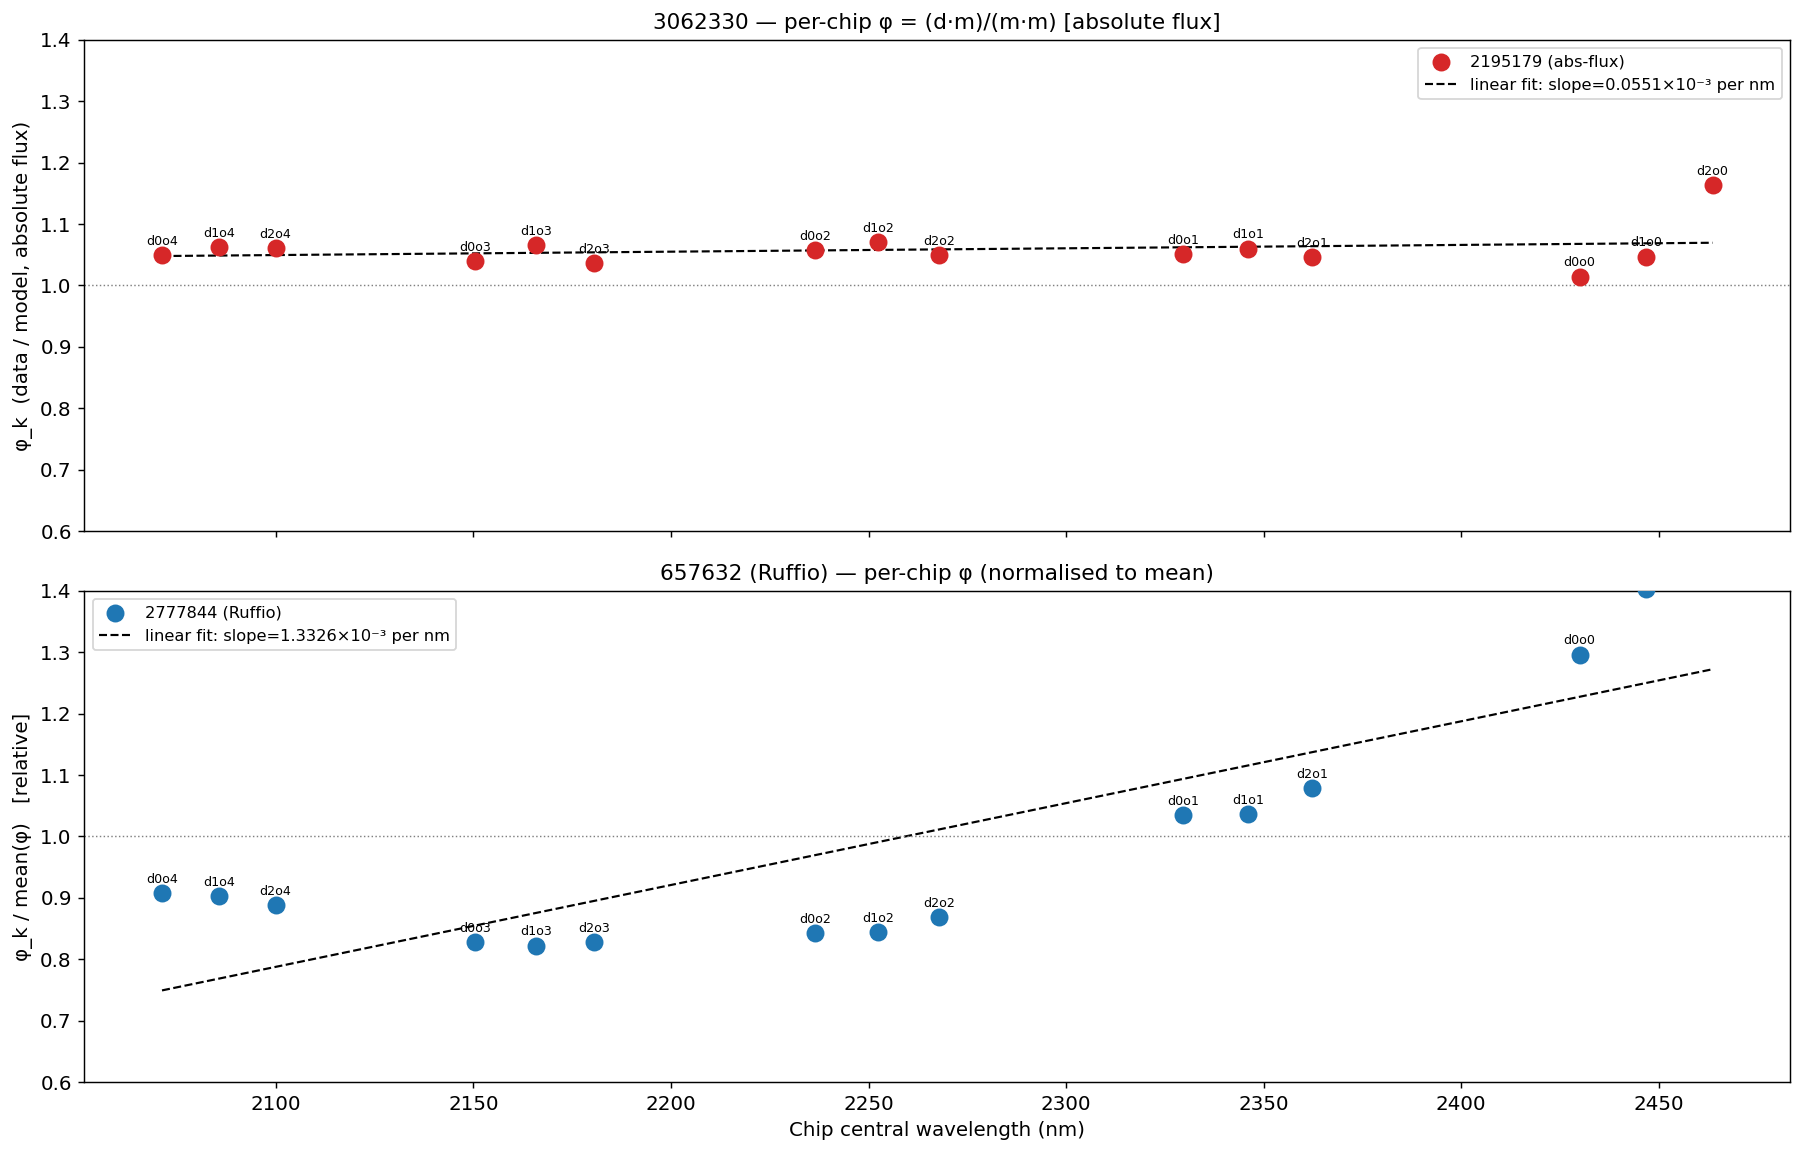

Saved.


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── Panel 1: 3062330 φ vs chip wavelength ────────────────────────────────
ax = axes[0]
wflat_C = wc_C.ravel()
pflat_C = phi_C.ravel()
ok      = np.isfinite(wflat_C) & np.isfinite(pflat_C)
ax.scatter(wflat_C[ok], pflat_C[ok], color=COL_C, s=80, zorder=5, label=LBL_C)

# label each chip
for d in range(nDet):
    for o in range(nOrd):
        if np.isfinite(phi_C[d,o]):
            ax.annotate(f'd{d}o{o}', (wc_C[d,o], phi_C[d,o]),
                        fontsize=7, ha='center', va='bottom', xytext=(0, 4),
                        textcoords='offset points')

# Fit a linear slope φ vs wavelength
w_ok = wflat_C[ok]
p_ok = pflat_C[ok]
p_coef = np.polyfit(w_ok, p_ok, 1)
w_fit  = np.linspace(w_ok.min(), w_ok.max(), 200)
ax.plot(w_fit, np.polyval(p_coef, w_fit), 'k--', lw=1.2,
        label=f'linear fit: slope={p_coef[0]*1e3:.4f}×10⁻³ per nm')

ax.axhline(1.0, color='gray', lw=0.8, ls=':')
ax.set_ylabel('φ_k  (data / model, absolute flux)')
ax.set_title('3062330 — per-chip φ = (d·m)/(m·m) [absolute flux]', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0.6, 1.4)

# ── Panel 2: 657632 φ vs chip wavelength (normalised) ────────────────────
ax = axes[1]
wflat_D = wc_D.ravel()
pflat_D = phi_D.ravel()
ok_D2   = np.isfinite(wflat_D) & np.isfinite(pflat_D)

# Normalise 657632 phi to its mean (since raw pRT model is in arbitrary units)
phi_D_norm = pflat_D / np.nanmean(pflat_D[ok_D2])
ax.scatter(wflat_D[ok_D2], phi_D_norm[ok_D2], color=COL_D, s=80, zorder=5, label=LBL_D)

for d in range(nDet):
    for o in range(nOrd):
        if np.isfinite(phi_D[d,o]):
            pn = phi_D[d,o] / np.nanmean(pflat_D[ok_D2])
            ax.annotate(f'd{d}o{o}', (wc_D[d,o], pn),
                        fontsize=7, ha='center', va='bottom', xytext=(0, 4),
                        textcoords='offset points')

p_coef_D = np.polyfit(wflat_D[ok_D2], phi_D_norm[ok_D2], 1)
w_fit_D  = np.linspace(wflat_D[ok_D2].min(), wflat_D[ok_D2].max(), 200)
ax.plot(w_fit_D, np.polyval(p_coef_D, w_fit_D), 'k--', lw=1.2,
        label=f'linear fit: slope={p_coef_D[0]*1e3:.4f}×10⁻³ per nm')

ax.axhline(1.0, color='gray', lw=0.8, ls=':')
ax.set_ylabel('φ_k / mean(φ)   [relative]')
ax.set_xlabel('Chip central wavelength (nm)')
ax.set_title('657632 (Ruffio) — per-chip φ (normalised to mean)', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0.6, 1.4)

plt.tight_layout()
plt.savefig(DIR_C.parent / 'validation_per_chip_phi.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved.')

### §4b  Compare φ slopes side-by-side

The key diagnostic: does 3062330 have a significant wavelength-dependent slope in φ that 657632 avoids?  
A positive slope means the model is **over-bright in the blue** relative to the data (or data is blue-faint), which would suppress 12CO/13CO because 13CO features are in the red K-band (2340–2370 nm).

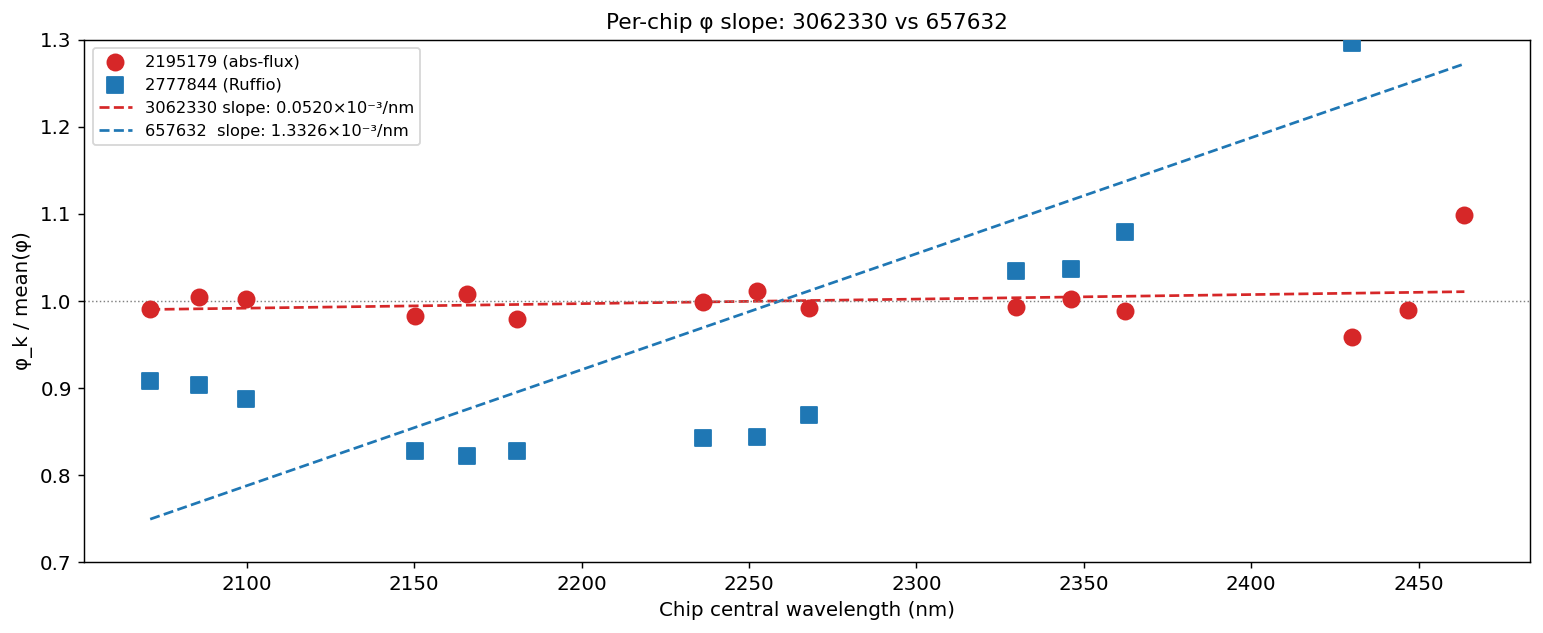

Saved.


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

# 3062330: normalise phi to its mean for fair comparison with 657632
phi_C_norm = pflat_C / np.nanmean(pflat_C[ok])

ax.scatter(wflat_C[ok], phi_C_norm[ok],   color=COL_C, s=80, zorder=5, label=LBL_C)
ax.scatter(wflat_D[ok_D2], phi_D_norm[ok_D2], color=COL_D, s=80, zorder=5, label=LBL_D, marker='s')

ax.plot(w_fit,   np.polyval(np.polyfit(wflat_C[ok], phi_C_norm[ok], 1), w_fit),
        color=COL_C, lw=1.5, ls='--',
        label=f'3062330 slope: {np.polyfit(wflat_C[ok], phi_C_norm[ok], 1)[0]*1e3:.4f}×10⁻³/nm')
ax.plot(w_fit_D, np.polyval(p_coef_D, w_fit_D),
        color=COL_D, lw=1.5, ls='--',
        label=f'657632  slope: {p_coef_D[0]*1e3:.4f}×10⁻³/nm')

ax.axhline(1.0, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Chip central wavelength (nm)')
ax.set_ylabel('φ_k / mean(φ)')
ax.set_title('Per-chip φ slope: 3062330 vs 657632', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0.7, 1.3)

plt.tight_layout()
plt.savefig(DIR_C.parent / 'validation_phi_slope_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved.')

## §5  13CO bandhead zoom (2338–2370 nm)

The 13CO bandhead falls across two chips: det1-ord1 (2338–2354 nm) and det2-ord1 (2355–2369 nm).  
We overlay both retrievals' models against the data to directly compare 13CO feature depths.

**Expected**: if 3062330 has deeper 13CO (lower 12CO/13CO = more 13CO), its model lines should be deeper than 657632's.

In [12]:
ZOOM_MIN, ZOOM_MAX = 2338.0, 2372.0

# Mask into zoom region
mask_d_z  = (wave_dn >= ZOOM_MIN) & (wave_dn <= ZOOM_MAX)
mask_C_z  = (wm_C >= ZOOM_MIN) & (wm_C <= ZOOM_MAX) & ok_C
mask_D_z  = (wm_D >= ZOOM_MIN) & (wm_D <= ZOOM_MAX) & ok_D

wz_d, fz_d = wave_dn[mask_d_z], flux_dn[mask_d_z]
wz_C, fz_C = wm_C[mask_C_z], fms_C[mask_C_z]   # 3062330: flux_scaled = flux (absolute, per-chip norm)
wz_D, fz_D = wm_D[mask_D_z], fms_D[mask_D_z]   # 657632: flux_scaled (per-chip scaled)

# Normalise 3062330 fms_C (= fm_C in W/m²/μm) to per-chip median in this zoom region
# so all three are on a comparable per-chip-normalised scale
fz_C_norm = fz_C / np.nanmedian(fz_C)
fz_D_norm = fz_D / np.nanmedian(fz_D)
fz_d_norm = fz_d / np.nanmedian(fz_d)

print(f'Zoom pixels: data={mask_d_z.sum()}, 3062330={mask_C_z.sum()}, 657632={mask_D_z.sum()}')

Zoom pixels: data=2895, 3062330=2895, 657632=2895


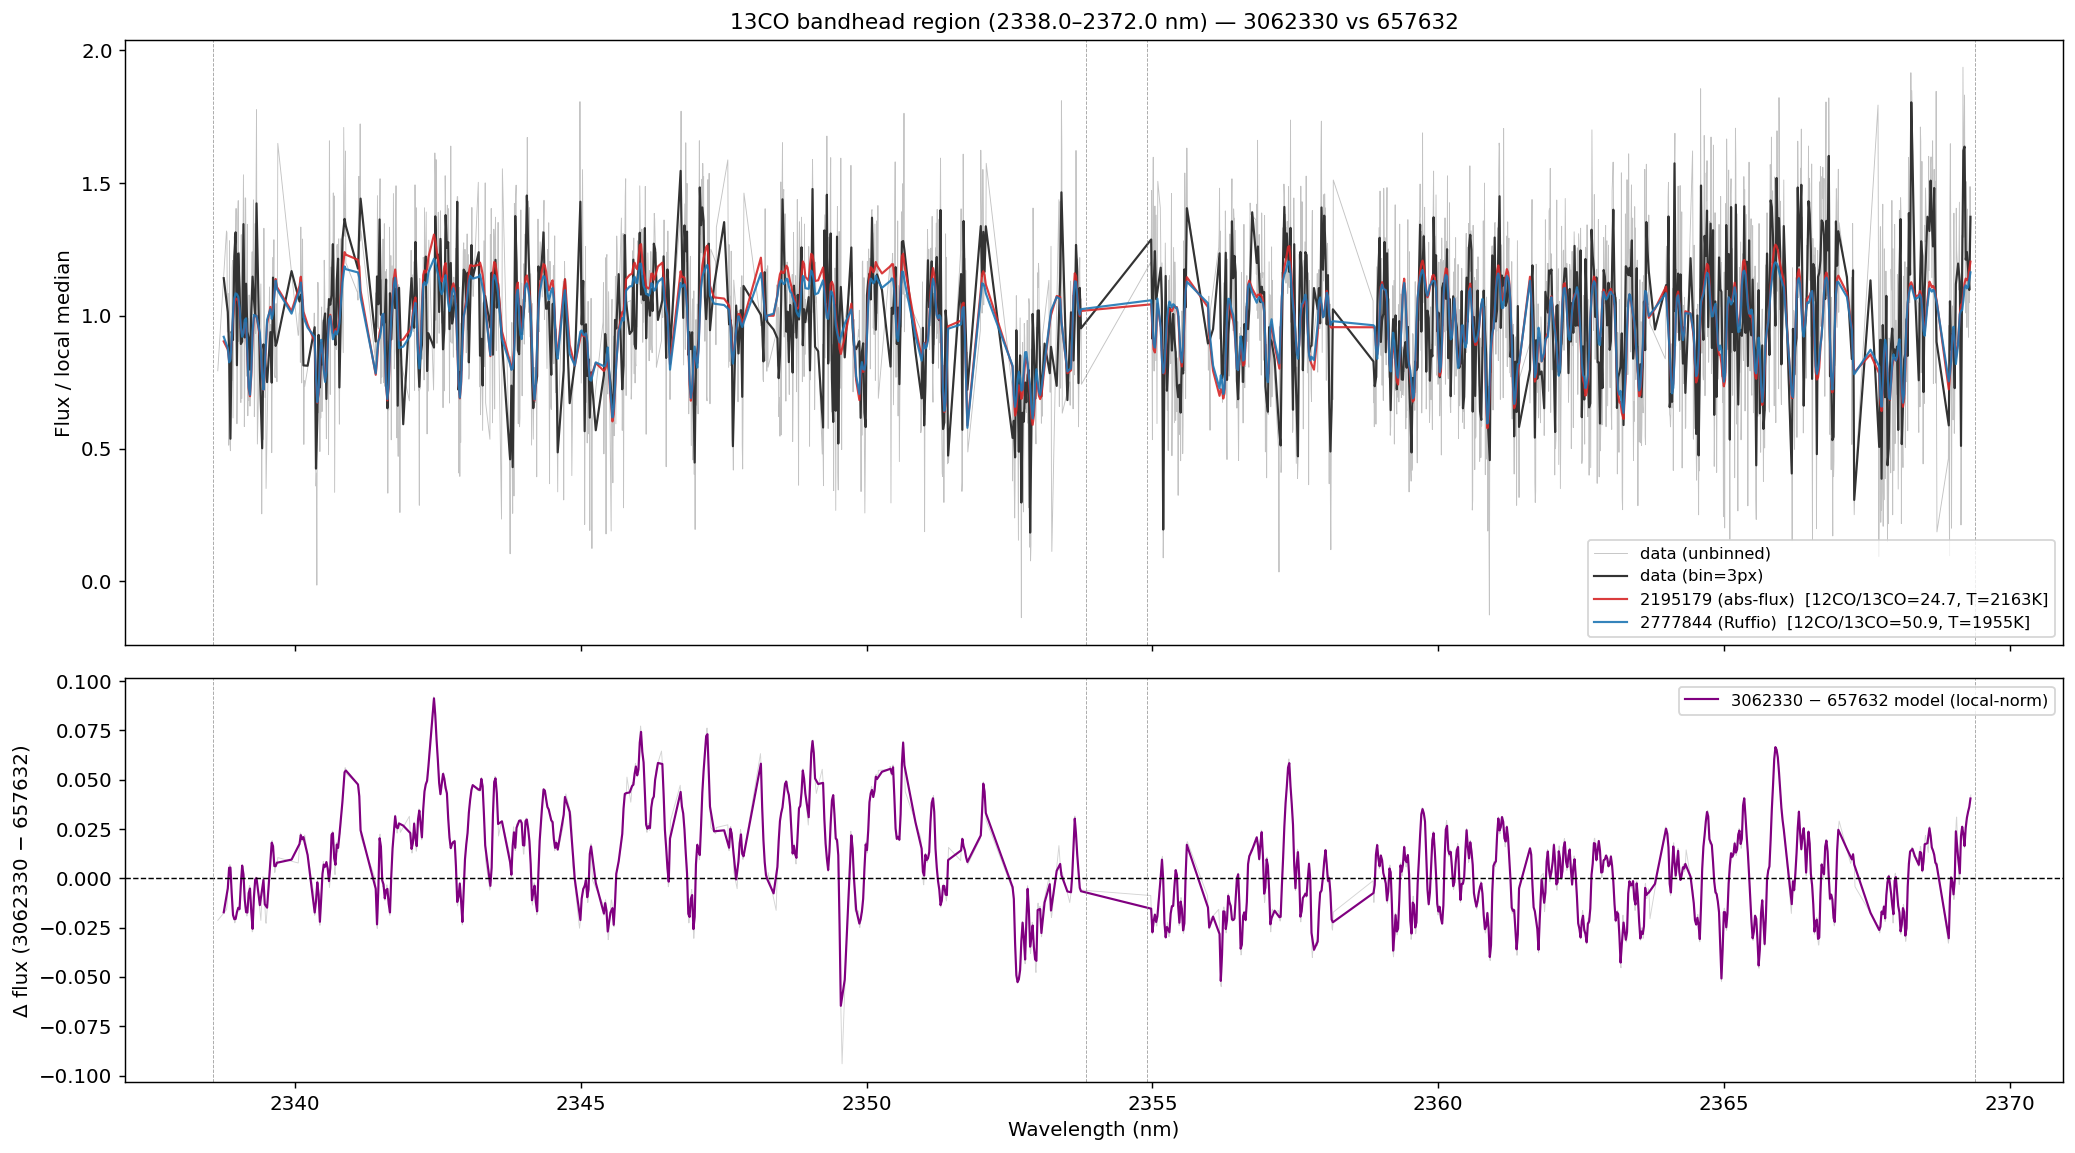

Saved.


In [13]:
BIN_Z = 3   # light binning for zoom

wb_dz, fb_dz = block_bin(wz_d, fz_d_norm, BIN_Z)
wb_Cz, fb_Cz = block_bin(wz_C, fz_C_norm, BIN_Z)
wb_Dz, fb_Dz = block_bin(wz_D, fz_D_norm, BIN_Z)

fig, axes = plt.subplots(2, 1, figsize=(16, 9),
                         gridspec_kw={'height_ratios': [3, 2]}, sharex=True)

# ── Top: spectrum ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(wz_d, fz_d_norm, color='#888', lw=0.5, alpha=0.5, label='data (unbinned)')
ax.plot(wb_dz, fb_dz, color='#333', lw=1.2, label=f'data (bin={BIN_Z}px)')
ax.plot(wb_Cz, fb_Cz, color=COL_C, lw=1.2, alpha=0.9, label=f'{LBL_C}  [12CO/13CO=24.7, T=2163K]')
ax.plot(wb_Dz, fb_Dz, color=COL_D, lw=1.2, alpha=0.9, label=f'{LBL_D}  [12CO/13CO=50.9, T=1955K]')

ax.set_ylabel('Flux / local median')
ax.set_title(f'13CO bandhead region ({ZOOM_MIN}–{ZOOM_MAX} nm) — 3062330 vs 657632', fontsize=12)
ax.legend(fontsize=9, loc='lower right')

# chip boundaries in zoom region
for d in range(nDet):
    for o in range(nOrd):
        w_chip = wave3d[d, o]
        w_lo = w_chip[w_chip > 0].min()
        w_hi = w_chip[w_chip > 0].max()
        if w_lo >= ZOOM_MIN and w_lo <= ZOOM_MAX:
            ax.axvline(w_lo, color='gray', lw=0.5, ls='--', alpha=0.7)
        if w_hi >= ZOOM_MIN and w_hi <= ZOOM_MAX:
            ax.axvline(w_hi, color='gray', lw=0.5, ls='--', alpha=0.7)

# ── Bottom: difference 3062330 − 657632 ─────────────────────────────────
ax = axes[1]
# Interpolate both models onto data wavelength grid
mC_on_d = np.interp(wz_d, wz_C, fz_C_norm)
mD_on_d = np.interp(wz_d, wz_D, fz_D_norm)
diff_CD = mC_on_d - mD_on_d
wb_diff, fb_diff = block_bin(wz_d, diff_CD, BIN_Z)

ax.plot(wz_d,   diff_CD, color='#aaa', lw=0.5, alpha=0.5)
ax.plot(wb_diff, fb_diff, color='purple', lw=1.2,
        label='3062330 − 657632 model (local-norm)')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_ylabel('Δ flux (3062330 − 657632)')
ax.set_xlabel('Wavelength (nm)')
ax.legend(fontsize=9)

for d in range(nDet):
    for o in range(nOrd):
        w_chip = wave3d[d, o]
        w_lo = w_chip[w_chip > 0].min()
        w_hi = w_chip[w_chip > 0].max()
        if w_lo >= ZOOM_MIN and w_lo <= ZOOM_MAX:
            ax.axvline(w_lo, color='gray', lw=0.5, ls='--', alpha=0.7)
        if w_hi >= ZOOM_MIN and w_hi <= ZOOM_MAX:
            ax.axvline(w_hi, color='gray', lw=0.5, ls='--', alpha=0.7)

plt.tight_layout()
plt.savefig(DIR_C.parent / 'validation_13CO_bandhead_zoom.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved.')

## §6  Residuals in 13CO region: which model fits the data better?

Compute chi² per pixel in the 13CO bandhead region for each retrieval to quantify the fit quality.

In [15]:
# Per-chip normalised data and error in the zoom region
err_norm3d = np.full_like(err3d, np.nan)
for d in range(nDet):
    for o in range(nOrd):
        if np.isfinite(chip_medians[d, o]):
            err_norm3d[d, o] = err3d[d, o] / chip_medians[d, o]

err_norm_flat = err_norm3d.ravel().copy()
valid_en = np.isfinite(err_norm_flat) & np.isfinite(wave_flat)
idx_en   = np.argsort(wave_flat[valid_en])
wave_en  = wave_flat[valid_en][idx_en]
err_en   = err_norm_flat[valid_en][idx_en]

# Restrict to zoom region where both wave and error are available
mask_e_z = (wave_en >= ZOOM_MIN) & (wave_en <= ZOOM_MAX)
wez = wave_en[mask_e_z]
eez = err_en[mask_e_z]

# Data (per-chip norm) on the same grid as errors
fdz_for_chi2 = np.interp(wez, wz_d, fz_d_norm)
mCz_for_chi2 = np.interp(wez, wz_C, fz_C_norm)
mDz_for_chi2 = np.interp(wez, wz_D, fz_D_norm)

good = np.isfinite(fdz_for_chi2) & np.isfinite(mCz_for_chi2) & np.isfinite(mDz_for_chi2) & (eez > 0)
res_C = fdz_for_chi2[good] - mCz_for_chi2[good]
res_D = fdz_for_chi2[good] - mDz_for_chi2[good]
chi2_C = np.mean((res_C / eez[good])**2)
chi2_D = np.mean((res_D / eez[good])**2)

print(f'13CO region ({ZOOM_MIN}–{ZOOM_MAX} nm), N={good.sum()} pixels')
print(f'  2195179 reduced χ²: {chi2_C:.3f}')
print(f'  2777844 reduced χ²: {chi2_D:.3f}')
print(f'  Difference: Δχ² = {chi2_C - chi2_D:.4f}')
print()
print('Mean residual in 13CO region:')
print(f'  2195179: {np.mean(res_C):.4f}  (positive → model too faint)')
print(f'  2777844:  {np.mean(res_D):.4f}  (positive → model too faint)')

13CO region (2338.0–2372.0 nm), N=2895 pixels
  2195179 reduced χ²: 4.320
  2777844 reduced χ²: 4.271
  Difference: Δχ² = 0.0488

Mean residual in 13CO region:
  2195179: 0.0071  (positive → model too faint)
  2777844:  0.0138  (positive → model too faint)


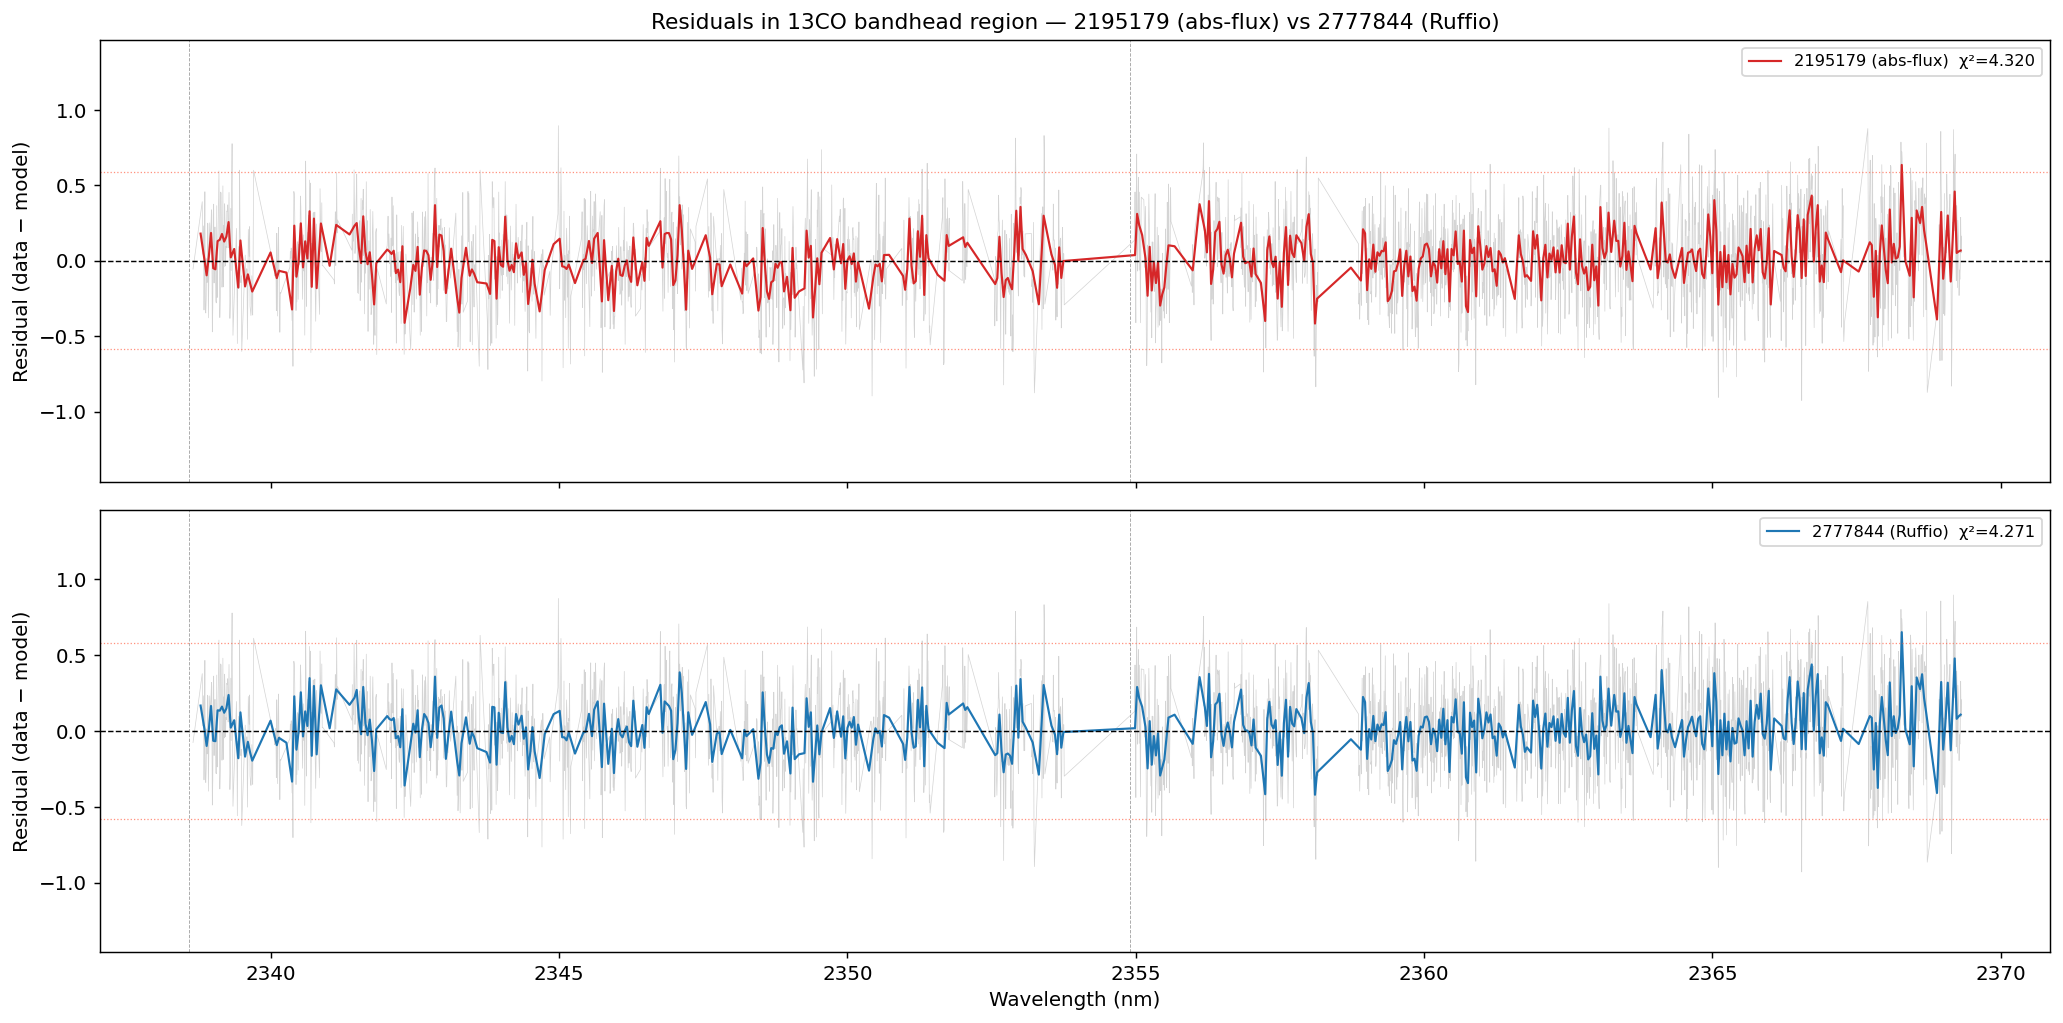

Saved.


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

BIN_R = 5
wb_rC, fb_rC = block_bin(wez[good], res_C, BIN_R)
wb_rD, fb_rD = block_bin(wez[good], res_D, BIN_R)

for ax_i, (res_i, wb_i, fb_i, col_i, lbl_i, chi2_i) in enumerate([
    (res_C, wb_rC, fb_rC, COL_C, LBL_C, chi2_C),
    (res_D, wb_rD, fb_rD, COL_D, LBL_D, chi2_D),
]):
    ax = axes[ax_i]
    ax.plot(wez[good], res_i, color='#aaa', lw=0.4, alpha=0.5)
    ax.plot(wb_i, fb_i, color=col_i, lw=1.2, label=f'{lbl_i}  χ²={chi2_i:.3f}')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    sig = np.std(res_i)
    ax.axhline( 2*sig, color='tomato', lw=0.7, ls=':', alpha=0.7)
    ax.axhline(-2*sig, color='tomato', lw=0.7, ls=':', alpha=0.7)
    ax.set_ylabel('Residual (data − model)')
    ax.legend(fontsize=9)
    ax.set_ylim(-5*sig, 5*sig)
    for d in range(nDet):
        for o in range(nOrd):
            w_chip = wave3d[d, o]
            w_lo = w_chip[w_chip > 0].min()
            if ZOOM_MIN <= w_lo <= ZOOM_MAX:
                ax.axvline(w_lo, color='gray', lw=0.5, ls='--', alpha=0.7)

axes[1].set_xlabel('Wavelength (nm)')
axes[0].set_title(f'Residuals in 13CO bandhead region — {LBL_C} vs {LBL_D}', fontsize=12)

plt.tight_layout()
plt.savefig(DIR_C.parent / 'validation_13CO_residuals.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved.')